# 📚 Système de Recommandation de Livres
### Projet : archives_library_v3

Ce notebook te guide **pas à pas** pour construire un système de recommandation de livres basé sur ton projet Django.

---

## 🗺️ Plan du notebook
1. Installation des dépendances
2. Connexion à la base de données Django
3. Exploration et préparation des données
4. Recommandation par **contenu** (Content-Based Filtering)


---
## ✅ ÉTAPE 1 — Installation des dépendances

Lance cette cellule **une seule fois** pour installer toutes les bibliothèques nécessaires.

In [1]:
# Installation des bibliothèques
!pip install pandas numpy scikit-learn scipy django joblib matplotlib seaborn

---
## ✅ ÉTAPE 2 — Connexion à la base de données Django

On configure Django pour pouvoir utiliser ses modèles directement dans Jupyter.

> ⚠️ **Important** : Mets à jour le chemin `BASE_DIR` avec le chemin réel de ton projet.

In [2]:
import pymysql
pymysql.install_as_MySQLdb()

import sys
import os
import django

# ======================================================
# 👇 MODIFIE CE CHEMIN avec le chemin de ton projet
BASE_DIR = r'C:\Users\SALMA KHATIBI\Downloads\archives_library_v3_fixed\library_updated'  # Windows
# BASE_DIR = '/home/user/library_updated'         # Linux/Mac
# ======================================================

sys.path.insert(0, BASE_DIR)
os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'archives_library.settings')

# Nécessaire pour utiliser Django dans Jupyter
os.environ["DJANGO_ALLOW_ASYNC_UNSAFE"] = "true"

django.setup()
print("✅ Django connecté avec succès !")

✅ Django connecté avec succès !


In [3]:
# Imports généraux
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Imports Django
from archives.models import Book, Author, Category, Review, Download, User

print("✅ Imports réussis !")
print(f"   📚 Livres en base     : {Book.objects.filter(is_approved=True).count()}")
print(f"   👤 Utilisateurs       : {User.objects.count()}")
print(f"   ⭐ Avis (reviews)     : {Review.objects.count()}")
print(f"   📥 Téléchargements    : {Download.objects.count()}")
print(f"   🏷️  Catégories         : {Category.objects.count()}")

✅ Imports réussis !
   📚 Livres en base     : 7
   👤 Utilisateurs       : 3
   ⭐ Avis (reviews)     : 1
   📥 Téléchargements    : 1
   🏷️  Catégories         : 4


---
## ✅ ÉTAPE 3 — Exploration et préparation des données

In [4]:
# ── 3.1  Charger les livres dans un DataFrame ──────────────────────────────

books_qs = Book.objects.filter(is_approved=True).prefetch_related('authors', 'category')

books_data = []
for book in books_qs:
    books_data.append({
        'book_id'       : book.id,
        'title'         : book.title,
        'description'   : book.description or '',
        'category'      : book.category.name if book.category else 'Inconnu',
        'language'      : book.language,
        'authors'       : ', '.join([a.name for a in book.authors.all()]),
        'publisher'     : book.publisher or '',
        'release_date'  : book.release_date or '',
        'download_count': book.download_count,
        'read_count'    : book.read_count,
        'like_count'    : book.like_count,
        'is_trending'   : book.is_trending,
        'is_featured'   : book.is_featured,
    })

df_books = pd.DataFrame(books_data)
print(f"✅ {len(df_books)} livres chargés")
df_books.head()

✅ 7 livres chargés


,book_id,title,description,category,language,authors,publisher,release_date,download_count,read_count,like_count,is_trending,is_featured
0,8,The Birth and Death of the Sun,The Birth and Death of the Sun is a classic po...,Science,en,George Gamow,Viking Press,1940,0,1,0,False,False
1,7,The Flowers of Buffoonery,The Flowers of Buffoonery takes place in a sea...,Fiction,en,Osamu Dazai,New Directions Publishing,2023,0,0,0,False,False
2,6,The Setting Sun,The Setting Sun is a powerful novel set in pos...,Fiction,en,Osamu Dazai,New Directions Publishing,1956,0,1,0,False,False
3,5,Schoolgirl,"Schoolgirl is a short, introspective novella t...",Fiction,en,Osamu Dazai,One Peace Books,2011,0,0,0,False,False
4,4,Blue Bamboo: Tales,Blue Bamboo: Tales is a collection of short st...,Fiction,en,Osamu Dazai,Kurodahan Press,2012,0,1,0,False,False


In [5]:
# ── 3.2  Charger les téléchargements (interactions utilisateur-livre) ───────

downloads_qs = Download.objects.select_related('user', 'book').all()

downloads_data = []
for d in downloads_qs:
    downloads_data.append({
        'user_id'    : d.user.id,
        'book_id'    : d.book.id,
        'downloaded_at': d.downloaded_at if hasattr(d, 'downloaded_at') else None,
    })

df_downloads = pd.DataFrame(downloads_data)
print(f"✅ {len(df_downloads)} téléchargements chargés")
df_downloads.head()

✅ 1 téléchargements chargés


,user_id,book_id,downloaded_at
0,2,2,2026-04-22 18:30:39.980247+00:00


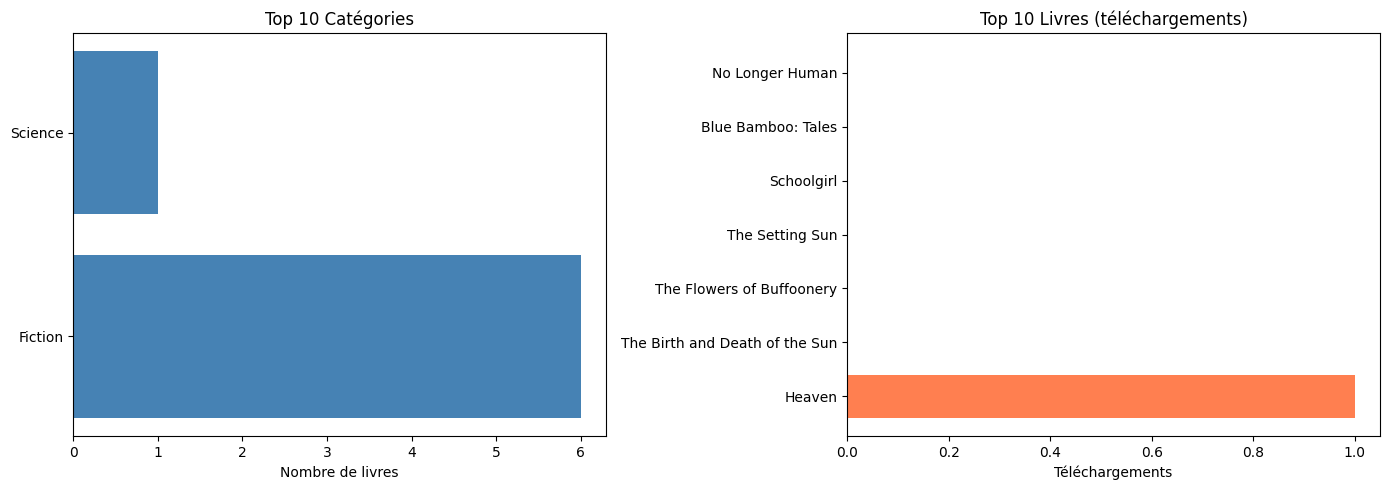

✅ Graphiques sauvegardés dans exploration_livres.png


In [6]:
# ── 3.3  Visualisation rapide ───────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution par catégorie
cat_counts = df_books['category'].value_counts().head(10)
axes[0].barh(cat_counts.index, cat_counts.values, color='steelblue')
axes[0].set_title('Top 10 Catégories')
axes[0].set_xlabel('Nombre de livres')

# Top livres par téléchargements
top_books = df_books.nlargest(10, 'download_count')[['title', 'download_count']]
axes[1].barh(top_books['title'].str[:30], top_books['download_count'], color='coral')
axes[1].set_title('Top 10 Livres (téléchargements)')
axes[1].set_xlabel('Téléchargements')

plt.tight_layout()
plt.savefig('exploration_livres.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Graphiques sauvegardés dans exploration_livres.png")

---
## ✅ ÉTAPE 4 — Méthode 1 : Recommandation par Contenu (Content-Based Filtering)

> **Principe** : On compare les livres entre eux selon leur description, catégorie et auteurs.  
> Si tu lis un livre de science-fiction, on te recommande d'autres livres similaires.

**Avantage** : Fonctionne même sans historique utilisateur.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ── 4.1  Construire le texte combiné de chaque livre ────────────────────────

def build_book_features(row):
    """
    Combine toutes les métadonnées d'un livre en un seul texte.
    On répète la catégorie et les auteurs pour leur donner plus de poids.
    """
    parts = [
        row['description'],
        row['category'] * 3,      # poids x3
        row['authors'] * 3,       # poids x3
        row['language'],
        row['publisher'],
    ]
    return ' '.join(str(p) for p in parts if p)

df_books['features'] = df_books.apply(build_book_features, axis=1)
print("✅ Features construites")
print("Exemple pour le premier livre :")
print(df_books['features'].iloc[0][:300])

✅ Features construites
Exemple pour le premier livre :
The Birth and Death of the Sun is a classic popular science book that explains the life cycle of stars, atomic theory, and the structure of the universe in a simple and engaging way. Written by physicist George Gamow, the book introduces complex concepts like stellar evolution and cosmology without 


In [8]:
# ── 4.2  Vectorisation TF-IDF ───────────────────────────────────────────────

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words=['the','a','an','and','or','but','in','on','at','to','for',
                'of','with','by','from','le','la','les','de','du','des','un','une'],
    ngram_range=(1, 2),   # unigrammes + bigrammes
    min_df=1,
)

tfidf_matrix = tfidf.fit_transform(df_books['features'])
print(f"✅ Matrice TF-IDF : {tfidf_matrix.shape}")
print(f"   → {tfidf_matrix.shape[0]} livres × {tfidf_matrix.shape[1]} termes")

✅ Matrice TF-IDF : (7, 565)
   → 7 livres × 565 termes


In [9]:
# ── 4.3  Calculer la similarité cosinus ─────────────────────────────────────

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print(f"✅ Matrice de similarité calculée : {cosine_sim.shape}")

# Index pour retrouver un livre par son ID
book_id_to_idx = pd.Series(df_books.index, index=df_books['book_id'])
idx_to_book_id = pd.Series(df_books['book_id'].values, index=df_books.index)

✅ Matrice de similarité calculée : (7, 7)


In [ ]:
# ── 4.4  Fonction de recommandation Content-Based ───────────────────────────

def recommend_content_based(book_id, n=5, min_score=0.5, show_details=True):
    """
    Retourne les N livres les plus similaires à book_id.
    
    Paramètres :
        book_id      : ID du livre de référence
        n            : nombre de recommandations
        min_score    : score minimum de similarité (par défaut 0.5)
        show_details : afficher un résumé dans le notebook
    """
    if book_id not in book_id_to_idx:
        print(f"❌ Livre ID {book_id} non trouvé.")
        return []
    
    idx = book_id_to_idx[book_id]
    
    # Scores de similarité pour tous les livres
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # Exclure le livre lui-même (score = 1.0) et filtrer par score minimum
    sim_scores = [(i, score) for i, score in sim_scores if i != idx and score >= min_score][:n]
    
    recommended_ids = [int(idx_to_book_id[i]) for i, _ in sim_scores]
    scores          = [round(score, 4) for _, score in sim_scores]
    
    if show_details:
        ref_title = df_books.loc[idx, 'title']
        print(f"\n📖 Livre de référence : '{ref_title}'")
        print(f"{'─'*60}")
        for rank, (bid, score) in enumerate(zip(recommended_ids, scores), 1):
            b = df_books[df_books['book_id'] == bid].iloc[0]
            print(f"  {rank}. [{score:.3f}] {b['title'][:50]}")
            print(f"       Catégorie : {b['category']} | Auteurs : {b['authors'][:40]}")
    
    return recommended_ids


# ── TEST ────────────────────────────────────────────────────────────────────
# Teste avec le premier livre disponible
first_book_id = df_books['book_id'].iloc[0]
print(f"Test avec le livre ID = {first_book_id}")
recommend_content_based(first_book_id, n=5)

Test avec le livre ID = 8

📖 Livre de référence : 'The Birth and Death of the Sun'
────────────────────────────────────────────────────────────
  1. [0.032] No Longer Human
       Catégorie : Fiction | Auteurs : Osamu Dazai
  2. [0.025] The Setting Sun
       Catégorie : Fiction | Auteurs : Osamu Dazai
  3. [0.021] Schoolgirl
       Catégorie : Fiction | Auteurs : Osamu Dazai
  4. [0.013] Blue Bamboo: Tales
       Catégorie : Fiction | Auteurs : Osamu Dazai
  5. [0.007] Heaven
       Catégorie : Fiction | Auteurs : Mieko Kawakami


[3, 6, 5, 4, 2]